In [1]:
from utils import variables, functions

# realod them (maybe have been updated)
import importlib
importlib.reload(functions)
importlib.reload(variables)

import numpy as np, os, json, pandas as pd, random, pickle, re, seaborn as sns
from IPython.display import clear_output
from sklearn.model_selection import ParameterGrid

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Torch
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Variables imported correctly.
Functions imported correctly.
Functions imported correctly.
Variables imported correctly.


In [2]:
# Load all the dataframes
confounds_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'confounds_df.csv'))
rois_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'rois_df.csv'))
functionals_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv'))
events_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'events_df.csv'))
trials_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'trials_df.csv'))

In [3]:
# Define the boundaries of the different rois
rois_sub1_sizes, rois_sub2_sizes, rois_sub3_sizes, rois_sub4_sizes = {}, {}, {}, {}
for i in range(len(rois_df)):
    if '1' in rois_df['subject'][i]:
        rois_sub1_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})
    if '2' in rois_df['subject'][i]:
        rois_sub2_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})
    if '3' in rois_df['subject'][i]:
        rois_sub3_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})
    if '4' in rois_df['subject'][i]:
        rois_sub4_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})

roi_aliases = {
    'LHLOC': 'LHLO',
    'RHLOC': 'RHLO',
    'LHRSC': 'LHRRSC',  
    'RHRSC': 'RHRRSC'
}

def normalize_roi_slices(roi_slices, roi_aliases):
    normalized = {}
    for k,v in roi_slices.items():
        normalized[k] = v
    # aggiungi alias
    for canonical, alias in roi_aliases.items():
        if alias in roi_slices:
            normalized[canonical] = roi_slices[alias]
    return normalized

# calculate the slices
def build_roi_slices(roi_boundaries):
    roi_names = list(roi_boundaries.keys())
    roi_sizes = list(roi_boundaries.values())
    offsets = np.cumsum([0] + roi_sizes)
    slices = {roi: slice(offsets[i], offsets[i+1]) for i, roi in enumerate(roi_names)}
    return slices

roi_slices_sub1 = normalize_roi_slices(build_roi_slices(rois_sub1_sizes), roi_aliases)
roi_slices_sub2 = normalize_roi_slices(build_roi_slices(rois_sub2_sizes), roi_aliases)
roi_slices_sub3 = normalize_roi_slices(build_roi_slices(rois_sub3_sizes), roi_aliases)
roi_slices_sub4 = normalize_roi_slices(build_roi_slices(rois_sub4_sizes), roi_aliases)

print(roi_slices_sub1)
print(roi_slices_sub2)
print(roi_slices_sub3)
print(roi_slices_sub4)
# {'LH_EarlyVis': slice(0,200, None), 'LH_LOC': slice(200,316, None), ...}
# None is the step. slixe has 3 arguments: start, stop, slice

list_roi_slices = [roi_slices_sub1, roi_slices_sub2, roi_slices_sub3, roi_slices_sub4]

# Each dictionary respects the order of ROIs with which the features have been extracted and concatenated.

{'LHEarlyVis': slice(0, 210, None), 'LHLOC': slice(210, 362, None), 'LHOPA': slice(362, 463, None), 'LHPPA': slice(463, 594, None), 'LHRSC': slice(594, 680, None), 'RHEarlyVis': slice(680, 965, None), 'RHLOC': slice(965, 1155, None), 'RHOPA': slice(1155, 1342, None), 'RHPPA': slice(1342, 1542, None), 'RHRSC': slice(1542, 1685, None)}
{'RHPPA': slice(0, 198, None), 'RHOPA': slice(198, 293, None), 'RHLO': slice(293, 676, None), 'RHEarlyVis': slice(676, 917, None), 'RHRRSC': slice(917, 1058, None), 'LHPPA': slice(1058, 1230, None), 'LHOPA': slice(1230, 1315, None), 'LHLO': slice(1315, 1538, None), 'LHEarlyVis': slice(1538, 1792, None), 'LHRSC': slice(1792, 1851, None), 'LHLOC': slice(1315, 1538, None), 'RHLOC': slice(293, 676, None), 'RHRSC': slice(917, 1058, None)}
{'RHRSC': slice(0, 116, None), 'RHPPA': slice(116, 277, None), 'RHLO': slice(277, 708, None), 'RHEarlyVis': slice(708, 1188, None), 'RHOPA': slice(1188, 1393, None), 'LHPPA': slice(1393, 1505, None), 'LHOPA': slice(1505, 1692,

In [4]:
# Define the order of the sequence of ROIs
roi_order = [
    ('LHEarlyVis','RHEarlyVis'),
    ('LHLOC','RHLOC'),
    ('LHOPA','RHOPA'),
    ('LHPPA','RHPPA'),
    ('LHRSC','RHRSC')
]

In [5]:
# Load the files
subjects_data = []
subjects_labels = []
for sub in ['1','2','3','4']:
    if os.path.exists(os.path.join(variables.BOLD5000_PATH, f'subject{sub}_features.pkl')):
        with open(os.path.join(variables.BOLD5000_PATH, f'subject{sub}_features.pkl'), "rb") as fp:
            data = pickle.load(fp)

        # Extract the elements
        f = data["features"]
        l = data["labels"]
        n = data["n_nans"]

        print(f"Number of runs for subject {sub}:", len(f))
        print(f"Number of labels for subject {sub} and first run:", len(l[0]),'\n')
        #print("Number of NaNs:", n)

        stacked_trials = []
        stacked_labels = []
        for trial, lab in zip(f,l):
            if trial is not None:
                stacked_trials.extend(trial)    # adds all the runs of a subject
                stacked_labels.extend(lab)


        sub_data = functions.slice_data(subject=int(sub), subject_data=stacked_trials, list_roi_slices=list_roi_slices, target_order=roi_order)

        subjects_data.append(sub_data)
        subjects_labels.append(stacked_labels)

    else:
        subjects_data.append(None)
        subjects_labels.append(None)

print(f'Len subjects_data: {len(subjects_data)}')
for i in range(len(subjects_data)):
    if subjects_data[i] is not None:
        print(f'SUBJECT {i+1}')
        print(f'Type subjects_data[{i}]: {type(subjects_data[i])} - Len: {len(subjects_data[i])}')
        
        # Print keys
        print(f'subjects_data[{i}].keys(): {list(subjects_data[i].keys())}\n')
        
        # prendi la prima chiave
        first_key = list(subjects_data[i].keys())[0]
        print(f'Type subjects_data[{i}][{first_key}]: {type(subjects_data[i][first_key])}')
        print(f'shape subjects_data[{i}][{first_key}]: {subjects_data[i][first_key].shape}\n')


Number of runs for subject 1: 142
Number of labels for subject 1 and first run: 22 

Number of runs for subject 2: 142
Number of labels for subject 2 and first run: 21 

Number of runs for subject 3: 142
Number of labels for subject 3 and first run: 22 

Number of runs for subject 4: 84
Number of labels for subject 4 and first run: 21 

Len subjects_data: 4
SUBJECT 1
Type subjects_data[0]: <class 'dict'> - Len: 5
subjects_data[0].keys(): [('LHEarlyVis', 'RHEarlyVis'), ('LHLOC', 'RHLOC'), ('LHOPA', 'RHOPA'), ('LHPPA', 'RHPPA'), ('LHRSC', 'RHRSC')]

Type subjects_data[0][('LHEarlyVis', 'RHEarlyVis')]: <class 'numpy.ndarray'>
shape subjects_data[0][('LHEarlyVis', 'RHEarlyVis')]: (3119, 495)

SUBJECT 2
Type subjects_data[1]: <class 'dict'> - Len: 5
subjects_data[1].keys(): [('LHEarlyVis', 'RHEarlyVis'), ('LHLOC', 'RHLOC'), ('LHOPA', 'RHOPA'), ('LHPPA', 'RHPPA'), ('LHRSC', 'RHRSC')]

Type subjects_data[1][('LHEarlyVis', 'RHEarlyVis')]: <class 'numpy.ndarray'>
shape subjects_data[1][('LHEarl

In [7]:
# Load the images features extracted in feature_extraction.ipynb
data = np.load(os.path.join(variables.BOLD5000_PATH,"image_features_resnet.npz"))
X_features = data['features']
y = data['labels']

print(f'X_features shape: {X_features.shape}')
print(f'y shape: {y.shape}')

X_features shape: (11193, 2048)
y shape: (11193,)


In [8]:
# Create a new column extracting the subject from the path
trials_df['subject'] = trials_df['events_path'].apply(
    lambda x: re.search(r'sub-(CSI\d+)', x).group(1))

trials_df.head(3)

,events_path,image_name,label,dataset,image_path,subject
0,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n01930112_19568.JPEG,animal or human,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...,CSI1
1,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n03733281_29214.JPEG,object,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...,CSI1
2,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n07695742_5848.JPEG,plant or food,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...,CSI1


In [9]:
top_idxs_all_rois_sub1, scores_all_rois_sub1 = functions.select_top_voxels_all_rois(subject=1, 
                                                                          k=100,
                                                                          roi_order=roi_order,
                                                                          subjects_data=subjects_data,
                                                                          images_features=X_features,
                                                                          images_labels=y,
                                                                          trials_df=trials_df)

top_idxs_all_rois_sub2, scores_all_rois_sub2 = functions.select_top_voxels_all_rois(subject=2, 
                                                                          k=100,
                                                                          roi_order=roi_order,
                                                                          subjects_data=subjects_data,
                                                                          images_features=X_features,
                                                                          images_labels=y,
                                                                          trials_df=trials_df)

top_idxs_all_rois_sub3, scores_all_rois_sub3 = functions.select_top_voxels_all_rois(subject=3, 
                                                                          k=100,
                                                                          roi_order=roi_order,
                                                                          subjects_data=subjects_data,
                                                                          images_features=X_features,
                                                                          images_labels=y,
                                                                          trials_df=trials_df)

top_idxs_all_rois_sub4, scores_all_rois_sub4 = functions.select_top_voxels_all_rois(subject=4, 
                                                                          k=100,
                                                                          roi_order=roi_order,
                                                                          subjects_data=subjects_data,
                                                                          images_features=X_features,
                                                                          images_labels=y,
                                                                          trials_df=trials_df)                    

Best Alpha for roi:('LHEarlyVis', 'RHEarlyVis') - subject 1: 100000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:('LHLOC', 'RHLOC') - subject 1: 10000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:('LHOPA', 'RHOPA') - subject 1: 10000.0


...

Best Alpha for roi:('LHPPA', 'RHPPA') - subject 3: 100000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:('LHRSC', 'RHRSC') - subject 3: 100000.0
Best Alpha for roi:('LHEarlyVis', 'RHEarlyVis') - subject 4: 100000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:('LHLOC', 'RHLOC') - subject 4: 100000.0
Best Alpha for roi:('LHOPA', 'RHOPA') - subject 4: 100000.0
Best Alpha for roi:('LHPPA', 'RHPPA') - subject 4: 100000.0
Best Alpha for roi:('LHRSC', 'RHRSC') - subject 4: 100000.0


In [13]:
final_rois_sub1, final_labels_sub1 = functions.extract_final_rois(subject=1, subjects_data=subjects_data, roi_order=roi_order, top_idxs_all_rois_sub=top_idxs_all_rois_sub1, trials_df=trials_df, images_labels=y)
print(f"final_rois_sub1 type: {type(final_rois_sub1)} - Length: {len(final_rois_sub1)}")
print(f"final_labels_sub1 type: {type(final_labels_sub1)} - Shape: {(final_labels_sub1).shape}\n")

final_rois_sub2, final_labels_sub2 = functions.extract_final_rois(subject=2, subjects_data=subjects_data, roi_order=roi_order, top_idxs_all_rois_sub=top_idxs_all_rois_sub2, trials_df=trials_df, images_labels=y)
print(f"final_rois_sub2 type: {type(final_rois_sub2)} - Length: {len(final_rois_sub2)}")
print(f"final_labels_sub2 type: {type(final_labels_sub2)} - Shape: {(final_labels_sub2).shape}\n")

final_rois_sub3, final_labels_sub3 = functions.extract_final_rois(subject=3, subjects_data=subjects_data, roi_order=roi_order, top_idxs_all_rois_sub=top_idxs_all_rois_sub3, trials_df=trials_df, images_labels=y)
print(f"final_rois_sub3 type: {type(final_rois_sub3)} - Length: {len(final_rois_sub3)}")
print(f"final_labels_sub3 type: {type(final_labels_sub3)} - Shape: {(final_labels_sub3).shape}\n")

final_rois_sub4, final_labels_sub4 = functions.extract_final_rois(subject=4, subjects_data=subjects_data, roi_order=roi_order, top_idxs_all_rois_sub=top_idxs_all_rois_sub4, trials_df=trials_df, images_labels=y)
print(f"final_rois_sub4 type: {type(final_rois_sub4)} - Length: {len(final_rois_sub4)}")
print(f"final_labels_sub4 type: {type(final_labels_sub4)} - Shape: {(final_labels_sub4).shape}")

Shape final ROI ('LHEarlyVis', 'RHEarlyVis') for subject 1: (3119, 100)
Shape final ROI ('LHLOC', 'RHLOC') for subject 1: (3119, 100)
Shape final ROI ('LHOPA', 'RHOPA') for subject 1: (3119, 100)
Shape final ROI ('LHPPA', 'RHPPA') for subject 1: (3119, 100)
Shape final ROI ('LHRSC', 'RHRSC') for subject 1: (3119, 100)
final_rois_sub1 type: <class 'list'> - Length: 5
final_labels_sub1 type: <class 'numpy.ndarray'> - Shape: (3119,)

Shape final ROI ('LHEarlyVis', 'RHEarlyVis') for subject 2: (3119, 100)
Shape final ROI ('LHLOC', 'RHLOC') for subject 2: (3119, 100)
Shape final ROI ('LHOPA', 'RHOPA') for subject 2: (3119, 100)
Shape final ROI ('LHPPA', 'RHPPA') for subject 2: (3119, 100)
Shape final ROI ('LHRSC', 'RHRSC') for subject 2: (3119, 100)
final_rois_sub2 type: <class 'list'> - Length: 5
final_labels_sub2 type: <class 'numpy.ndarray'> - Shape: (3119,)

Shape final ROI ('LHEarlyVis', 'RHEarlyVis') for subject 3: (3121, 100)
Shape final ROI ('LHLOC', 'RHLOC') for subject 3: (3121, 1

Now, the data are divided in ROIs, since each ROI will correspond to a node in the BRNN.

They are NOT divided in right and left hemisphere (as in the case of multibranch GNN), since this is the notebook for the simple GNN.

Each node will receive in input data of dimension 100.

And there are 11193 samples ( = number of trials, that is number of presente dimages among all the sessions in the BOLD5000 study ) .

In [14]:
# Concatenate creating a list of 5 matrixes, all of shape (n_total_trials, 100)
final_voxels_data = []
for i in range(5):
    final_voxels_data.append(np.concatenate((final_rois_sub1[i], final_rois_sub2[i], final_rois_sub3[i], final_rois_sub4[i]), axis=0))

final_labels=np.concatenate((final_labels_sub1, final_labels_sub2, final_labels_sub3, final_labels_sub4), axis=0)

print(f'final_voxels_data length: {len(final_voxels_data)}')
print(f'final_labels length: {len(final_labels)}\n')
for i in range(len(final_voxels_data)):
    print(f'final_voxels_data[{i}].shape: {final_voxels_data[i].shape}')

print(f'\nfinal_labels.shape: {final_labels.shape}')

final_voxels_data length: 5
final_labels length: 11193

final_voxels_data[0].shape: (11193, 100)
final_voxels_data[1].shape: (11193, 100)
final_voxels_data[2].shape: (11193, 100)
final_voxels_data[3].shape: (11193, 100)
final_voxels_data[4].shape: (11193, 100)

final_labels.shape: (11193,)


In [15]:
# Build a sequence array to give in input to the BRNN ((n_trials, seq_len=5, input_size=100))
X_seq = np.stack(final_voxels_data, axis=1)  # -> (n_trials, 5, 100)
print('X_seq shape:', X_seq.shape)

    # AT THE END I DIDNT DO THIS STEP OF MERGING.
# Merge some labels: 'food' + 'plant' -> 'food_plant', and 'animal' + 'human0' -> 'animal_human'
# This creates a new label array (labels_merged) and uses it for encoding
labels_list = [str(l) for l in final_labels]
labels_merged = labels_list
print('Unique labels after merge:', sorted(set(labels_merged)))

# Encode labels as integers using the merged labels
le = LabelEncoder()
y_numeric = le.fit_transform(labels_merged)
print('Classes (after merge):', list(le.classes_))
print(f'Type of y_numeric: {type(y_numeric)} - Shape: {y_numeric.shape}')
print(f'First ten numeric labels: {y_numeric[:10]}')
assert X_seq.shape[0] == len(y_numeric), f"Mismatch: X rows {X_seq.shape[0]} vs y {len(y_numeric)}"

X_seq shape: (11193, 5, 100)
Unique labels after merge: ['animal or human', 'object', 'plant or food', 'scene']
Classes (after merge): ['animal or human', 'object', 'plant or food', 'scene']
Type of y_numeric: <class 'numpy.ndarray'> - Shape: (11193,)
First ten numeric labels: [0 1 2 0 0 0 3 3 3 3]


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Class weights
classes, counts = np.unique(y_numeric, return_counts=True)
print("Class distribution:", dict(zip(classes, counts)))

# Calcolo pesi inversi alla frequenza
class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum() * len(classes)  # normalizzazione

# Converti in tensore PyTorch
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights_t)

Class distribution: {0: 2905, 1: 2420, 2: 1286, 3: 4582}
Class weights: tensor([0.7853, 0.9427, 1.7740, 0.4979], device='cuda:0')


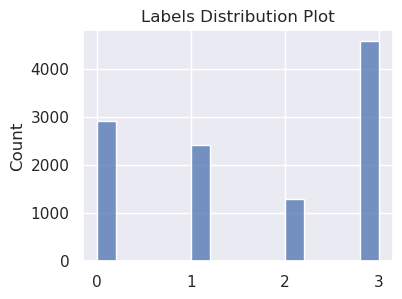

In [17]:
sns.set(rc={"figure.figsize": (4,3)})
sns.histplot(y_numeric)
plt.title("Labels Distribution Plot")
plt.show()

In [18]:
# Split train/test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_seq, y_numeric,
    test_size=0.2,
    stratify=y_numeric,
    random_state=42
)

print("Train seq:", X_trainval.shape)
print("Test seq:", X_test.shape, "\n")
print("Train y:", y_trainval.shape)
print("Test  y:", y_test.shape)

assert (len(X_trainval)+len(X_test)) == len(X_seq)
assert len(X_trainval) == len(y_trainval)

Train seq: (8954, 5, 100)
Test seq: (2239, 5, 100) 

Train y: (8954,)
Test  y: (2239,)


https://direct.mit.edu/netn/article/2/4/513/5426/Regions-of-Interest-as-nodes-of-dynamic-functional

#### BRNN Architecture

https://www.codegenes.net/blog/brnn-pytorch/

A BRNN consists of two separate RNNs: a forward RNN and a backward RNN.

The forward one processes the input sequence from the first time step to the last. The backward from the last to the first step of the sequence.

The outputs of the two networks are concatenated before classification, in this case.

https://medium.com/data-science/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

In [19]:
class BRNN(nn.Module):
    '''
    Args: 
        input_size: number of features expected in the input x
        hidden_size: number of features in the hidden state h
        num_layers: number of recurrent layers
        batch_first: if Trye, the input and output tensors are provided as (batch, seq, feature)
        bidirectional: if True, becomed a bidirectional RNN
        dropout: if non-zero, introduces a dropout layer on the outputs of each RNN layer, except the last one.
    '''

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(BRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size*2, num_classes)
 
    def forward(self, x):
        h0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(x.device)
 
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out)
        out = self.fc(out[:, -1, :])

        return out

##### Grid Search

In [20]:
def train_grid_search_brnn(grid_params, num_classes, n_epochs, X_seq, labels_numeric, device):

    # Since the class are unbalanced I will chose the best model as the one with the highest F1 score (macro)
    best_params = None
    best_val_f1 = 0
    best_val_acc = 0
    
    for i, params in enumerate(ParameterGrid(grid_params)):

        print(f'Combination {i+1}/{len(ParameterGrid(grid_params))} - Params: {params}')

        # Normalization
        n_trials, seq_len, n_voxels = X_seq.shape
        X_reshaped = X_seq.reshape(-1, n_voxels)

        # z-score voxel-wise
        if params['normalization'] in ['z_score', 'z']:
                X_norm = (X_reshaped - X_reshaped.mean(axis=0)) / X_reshaped.std(axis=0)
                X_seq[:] = X_norm.reshape(n_trials, seq_len, n_voxels)

        # min-max normalization voxel-wise
        elif params['normalization'] == 'min_max':
                X_norm = (X_reshaped - X_reshaped.min(axis=0)) / (X_reshaped.max(axis=0) - X_reshaped.min(axis=0))
                X_seq[:] = X_norm.reshape(n_trials, seq_len, n_voxels)

        if i==0:
             print(f'Shape after normalization {params['normalization']}: {X_seq.shape}')

        # Convert data in torch tensors
        X_t = torch.tensor(X_seq, dtype=torch.float32)
        y_t = torch.tensor(labels_numeric, dtype=torch.long)

        # Split train/val
        X_train, X_val, y_train, y_val = train_test_split(X_seq, labels_numeric, test_size=0.2, stratify=labels_numeric, random_state=42)

        # Compute class weights from training labels only
        class_counts = np.bincount(y_train)
        class_weights = 1.0 / class_counts
        class_weights = class_weights / class_weights.sum()  # normalize

        class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
        print("Class weights:", class_weights)


        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.long)
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.long)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        val_dataset = TensorDataset(X_val_t, y_val_t)

        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
        
        # Class weights
        criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))

        # Model, optimizer and scheduler
        model = BRNN(input_size=X_train_t.shape[-1],
                                hidden_size=params['hidden_size'],
                                num_layers=params['num_layers'],
                                num_classes=num_classes,
                                dropout=params['dropout']).to(device)
        optimizer = params['optimizer'](model.parameters(), lr=params['lr'])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


        # Training loop
        for epoch in range(n_epochs):
            # Training
            model.train()
            train_loss, correct, total = 0.0, 0, 0
            train_preds, train_labels = [], []
            
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                optimizer.zero_grad()

                outputs = model(Xb)
                loss = criterion(outputs, yb)
                loss.backward()

                optimizer.step()
                preds = outputs.argmax(dim=1)
                correct += (preds == yb).sum().item()

                train_loss += loss.item() * Xb.size(0)
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(yb.cpu().numpy())

                total += yb.size(0)

            train_loss /= len(train_dataset)
            train_acc = correct / total

            train_acc = accuracy_score(train_labels, train_preds)
            train_prec = precision_score(train_labels, train_preds, average="macro", zero_division=0)
            train_rec = recall_score(train_labels, train_preds, average="macro", zero_division=0)
            train_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

            # Validation
            model.eval()
            val_loss, correct, total = 0.0, 0, 0
            val_preds, val_labels = [], []

            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb, yb = Xb.to(device), yb.to(device)
                    outputs = model(Xb)
                    loss = criterion(outputs, yb)
                    val_loss += loss.item() * Xb.size(0)
                    preds = outputs.argmax(dim=1)
                    correct += (preds == yb).sum().item()
                    total += yb.size(0)

                    val_preds.extend(preds.cpu().numpy())
                    val_labels.extend(yb.cpu().numpy())

            val_loss /= len(val_dataset)
            val_acc = correct / total

            val_acc = accuracy_score(val_labels, val_preds)
            val_prec = precision_score(val_labels, val_preds, average="macro", zero_division=0)
            val_rec = recall_score(val_labels, val_preds, average="macro", zero_division=0)
            val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

            # Scheduler step
            scheduler.step(val_loss)

            # Save the best one
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_params = params
                best_val_acc = val_acc

  
            # Print metrics
            print(f"Epoch {epoch:3d}/{n_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        
        print('\n')

    return best_params, best_val_f1, best_val_acc        

In [21]:
grid_params = {
    'normalization': ['z_score', 'min_max'],
    'hidden_size': [16, 32],
    'num_layers': [1, 2],
    'dropout': [0.5],
    'batch_size': [32, 64],
    'optimizer': [torch.optim.Adam, torch.optim.SGD],
    'lr': [0.001, 0.0001]
}

num_classes = len(list(le.classes_))

print(f'Number of combinations: {len(ParameterGrid(grid_params))}\n')

device = "cuda" if torch.cuda.is_available() else "cpu"
if not os.path.exists(os.path.join(variables.BOLD5000_PATH, 'best_params_brnn.txt')):
    best_params, best_val_f1, best_val_acc = train_grid_search_brnn(grid_params, num_classes=4, n_epochs=30, X_seq=X_trainval, labels_numeric=y_trainval, device=device)

    # Cannot save in json file a class "optim", convert everything to string
    best_params_string = {}
    for key in best_params.keys():
        best_params_string[key] = str(best_params[key])

    # Save the best params in string format
    with open(os.path.join(variables.BOLD5000_PATH, 'best_params_brnn.txt'), 'w') as file:
        json.dump(best_params_string, file)

else: # Load best params 
    with open(os.path.join(variables.BOLD5000_PATH, 'best_params_brnn.txt'), "r") as f: best_params = eval(f.read()) 
    print("Loaded best BRNN parameters:", best_params)


    print(f'Best params: {best_params}')

Number of combinations: 64

Loaded best BRNN parameters: {'batch_size': '32', 'dropout': '0.5', 'hidden_size': '32', 'lr': '0.001', 'normalization': 'z_score', 'num_layers': '1', 'optimizer': "<class 'torch.optim.adam.Adam'>"}
Best params: {'batch_size': '32', 'dropout': '0.5', 'hidden_size': '32', 'lr': '0.001', 'normalization': 'z_score', 'num_layers': '1', 'optimizer': "<class 'torch.optim.adam.Adam'>"}


##### Train best model

In [24]:
def train_best_brnn(n_epochs, best_params, X_seq, labels_numeric, device= "cuda"):
   
    if True:

        print(f' -  Params: {best_params}')

        # Normalization
        n_trials, seq_len, n_voxels = X_seq.shape
        X_reshaped = X_seq.reshape(-1, n_voxels)

        # z-score voxel-wise
        if best_params['normalization'] in ['z_score', 'z']:
                X_norm = (X_reshaped - X_reshaped.mean(axis=0)) / X_reshaped.std(axis=0)
                X_seq[:] = X_norm.reshape(n_trials, seq_len, n_voxels)

        # min-max normalization voxel-wise
        elif best_params['normalization'] == 'min_max':
                X_norm = (X_reshaped - X_reshaped.min(axis=0)) / (X_reshaped.max(axis=0) - X_reshaped.min(axis=0))
                X_seq[:] = X_norm.reshape(n_trials, seq_len, n_voxels)

        if i==0:
             print(f'Shape after normalization {best_params['normalization']}: {X_seq.shape}')

        # Convert data in torch tensors
        X_t = torch.tensor(X_seq, dtype=torch.float32)
        y_t = torch.tensor(labels_numeric, dtype=torch.long)

        # Split train/val
        X_train, X_val, y_train, y_val = train_test_split(X_seq, labels_numeric, test_size=0.2, stratify=labels_numeric, random_state=42)

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.long)
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.long)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        val_dataset = TensorDataset(X_val_t, y_val_t)

        train_loader = DataLoader(train_dataset, batch_size=int(best_params['batch_size']), shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=int(best_params['batch_size']), shuffle=False)
        
        # Class weights
        criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))

        # Model, optimizer and scheduler
        model = BRNN(input_size=X_train_t.shape[-1],
                                hidden_size=int(best_params['hidden_size']),
                                num_layers=int(best_params['num_layers']),
                                num_classes=num_classes,
                                dropout=float(best_params['dropout'])).to(device)
        optimizer = best_params['optimizer'](model.parameters(), lr=best_params['lr'])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=8)


        train_losses, train_accs, train_f1s, val_losses, val_accs, val_f1s = [], [], [], [], [], []

        # For restoring best weights
        best_val_f1 = 0.0
        best_model_state = None
        best_epoch = 0

        # Training loop
        for epoch in range(n_epochs):
            # Training
            model.train()
            train_loss, correct, total = 0.0, 0, 0
            train_preds, train_labels = [], []
            
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                optimizer.zero_grad()

                outputs = model(Xb)
                loss = criterion(outputs, yb)
                loss.backward()

                optimizer.step()
                preds = outputs.argmax(dim=1)
                correct += (preds == yb).sum().item()

                train_loss += loss.item() * Xb.size(0)
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(yb.cpu().numpy())

                total += yb.size(0)

            train_loss /= len(train_dataset)
            train_acc = correct / total

            train_acc = accuracy_score(train_labels, train_preds)
            train_prec = precision_score(train_labels, train_preds, average="macro", zero_division=0)
            train_rec = recall_score(train_labels, train_preds, average="macro", zero_division=0)
            train_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

            train_accs.append(train_acc)
            train_losses.append(train_loss)
            train_f1s.append(train_f1)

            # Validation
            model.eval()
            val_loss, correct, total = 0.0, 0, 0
            val_preds, val_labels = [], []

            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb, yb = Xb.to(device), yb.to(device)
                    outputs = model(Xb)
                    loss = criterion(outputs, yb)
                    val_loss += loss.item() * Xb.size(0)
                    preds = outputs.argmax(dim=1)
                    correct += (preds == yb).sum().item()
                    total += yb.size(0)

                    val_preds.extend(preds.cpu().numpy())
                    val_labels.extend(yb.cpu().numpy())

            val_loss /= len(val_dataset)
            val_acc = correct / total

            val_acc = accuracy_score(val_labels, val_preds)
            val_prec = precision_score(val_labels, val_preds, average="macro", zero_division=0)
            val_rec = recall_score(val_labels, val_preds, average="macro", zero_division=0)
            val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

            val_accs.append(val_acc)
            val_losses.append(val_loss)
            val_f1s.append(val_f1)


            # For restoring best weights
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict()
                best_epoch = epoch

            # Scheduler step
            scheduler.step(val_loss)

            # Print metrics
            print(f"Epoch {epoch:3d}/{n_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        
        # At the end of the training, restore the best weights
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"Restored best model with F1 = {best_val_f1:.4f} at epoch {best_epoch}")

        torch.save(model.state_dict(), "/workspace/devcontainer-bigdata/models/best_model_brnn.pt")
        
        print('\n')

        # Plots
        fig, axes = plt.subplots(1,3, figsize=(14,4))
        axes = axes.flatten()
        # Losses
        axes[0].plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', color='forestgreen')
        axes[0].plot(range(1, len(train_losses)+1), val_losses, label='Validation Loss', color='navy')
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # F1 scores
        axes[1].plot(range(1, len(train_losses)+1), train_f1s, label='Training F1', color='forestgreen')
        axes[1].plot(range(1, len(train_losses)+1), val_f1s, label='Validation F1', color='navy')
        axes[1].set_title("F1 Score")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1 Score")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Accuracies
        axes[2].plot(range(1, len(train_losses)+1), train_accs, label='Training Acc', color='forestgreen')
        axes[2].plot(range(1, len(train_losses)+1), val_accs, label='Validation Acc', color='navy')
        axes[2].set_title("Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("F1 Score")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.6)      

In [27]:
best_params = {
    'batch_size': 32,                 # int
    'dropout': 0.5,                   # float
    'hidden_size': 32,                # int
    'lr': 0.001,                      # float
    'normalization': 'z_score',       # string 
    'num_layers': 1,                  # int
    'optimizer': torch.optim.Adam     # class
}

 -  Params: {'batch_size': 32, 'dropout': 0.5, 'hidden_size': 32, 'lr': 0.001, 'normalization': 'z_score', 'num_layers': 1, 'optimizer': <class 'torch.optim.adam.Adam'>}
Epoch   0/100       Train Loss:    1.3506  -  Train Acc:  0.393  -  Train F1:  0.330             Val Loss:    1.3086  -  Val Acc:  0.457  -  Val F1:  0.353
Epoch   1/100       Train Loss:    1.2813  -  Train Acc:  0.470  -  Train F1:  0.393             Val Loss:    1.2506  -  Val Acc:  0.492  -  Val F1:  0.407
Epoch   2/100       Train Loss:    1.2096  -  Train Acc:  0.516  -  Train F1:  0.436             Val Loss:    1.1920  -  Val Acc:  0.509  -  Val F1:  0.428
Epoch   3/100       Train Loss:    1.1429  -  Train Acc:  0.550  -  Train F1:  0.476             Val Loss:    1.1703  -  Val Acc:  0.530  -  Val F1:  0.453
Epoch   4/100       Train Loss:    1.0984  -  Train Acc:  0.571  -  Train F1:  0.500             Val Loss:    1.1613  -  Val Acc:  0.536  -  Val F1:  0.461
Epoch   5/100       Train Loss:    1.0522  -  Trai

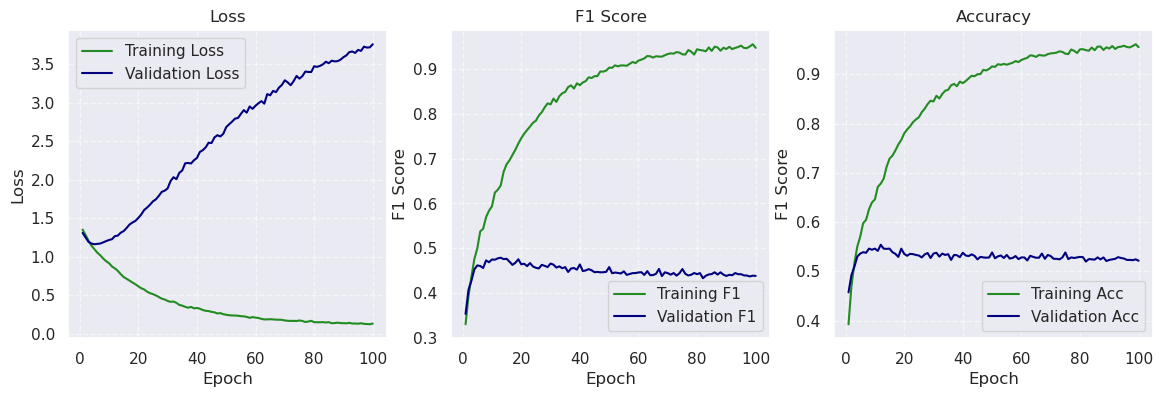

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_best_brnn(n_epochs=100, best_params=best_params, X_seq=X_trainval,
               labels_numeric = y_trainval, device = device)

##### Test

In [33]:
best_params = {
    'batch_size': 32,
    'dropout': 0.5,
    'hidden_size': 32,
    'lr': 0.001,
    'normalization': 'z_score',
    'num_layers': 1,
    'optimizer': torch.optim.Adam
}

In [34]:
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_test_t, y_test_t)
        
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the model
model = BRNN(
    input_size=X_test_t.shape[-1],
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    num_classes=num_classes,
    dropout=best_params['dropout']
).to(device)

model.load_state_dict(torch.load("/workspace/devcontainer-bigdata/models/best_model_brnn.pt"))
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


/tmp/ipykernel_5638/35478560.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/workspace/devcontainer-bigdata/models/best_model_brnn.pt

In [36]:
# Test
all_preds = []
all_labels = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        outputs = model(Xb)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average="macro")
prec = precision_score(all_labels, all_preds, average="macro")
rec  = recall_score(all_labels, all_preds, average="macro")

print("\n Test results: \n")
print(f"Accuracy:   {acc:.4f}")
print(f"F1-macro:   {f1:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")


 Test results: 

Accuracy:   0.3448
F1-macro:   0.2815
Precision:  0.3042
Recall:     0.2896
